# L-Maze: Value and Policy Iteration

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

from gym_classics.animation import gridworld_animate

## Define the L-Maze

To define the maze, we extend the abstract Gridworld class, define the maze layout and overwrite several internal methods.

In [3]:
from gym_classics.envs.abstract.gridworld import Gridworld

class LMazeGridworld(Gridworld):
    layout = """
|          |
|        G |
|          |
| XXXXXX   |
|      X   |
|      X   |
|      X   |
|  S   X   |
|      X   |
|          |
"""

    def __init__(self):
        super().__init__(self.layout, n_actions = 4)
        
    def _next_state(self, state, action):
        next_state = self._move(state, action)
        if self._is_blocked(next_state):
            next_state = state
        
        # clamp checks if the coordinate is out of bounds. 1.0 is the probability.
        return self._clamp(next_state), 1.0

    def _reward(self, state, action, next_state):      
        return {list(self._goals)[0]: +1.0}.get(next_state, 0.0)

    def _done(self, state, action, next_state):
        return next_state in self._goals  

gym.register('LMaze-v0', entry_point=LMazeGridworld)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment LMaze-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


We can use `make()` to create registered environments. Gymnasium uses wrappers, so we have unwrap the environment first to get the extended model API.

In [4]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

Visualize the layout with state ids.

## Value Iteration

In [5]:
from gym_classics.algorithms.dynamic_programming import value_iteration
from gym_classics.algorithms.policy import greedy_policy

V_star = value_iteration(env, discount=.8)

Value Iteration: 0it [00:00, ?it/s]

Value Iteration: 17it [00:00, 394.48it/s]


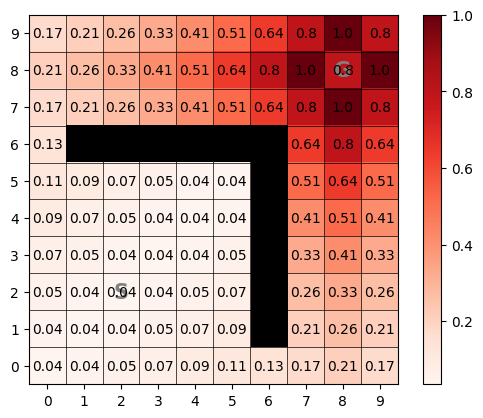

In [6]:
env.image(V_star, labels=True)

Find the optimal policy given the optimal value function.

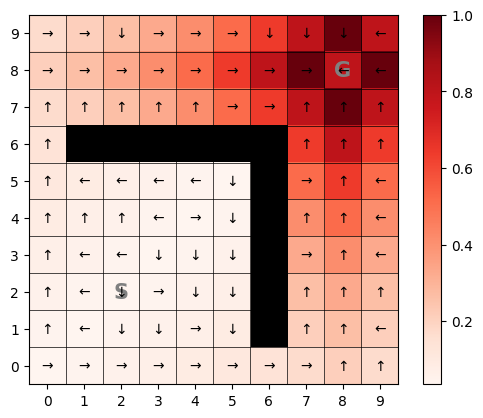

In [7]:
pol_star = greedy_policy(env, V_star)
env.image(V_star, policy=pol_star)

Look at the found path if you follow the policy.

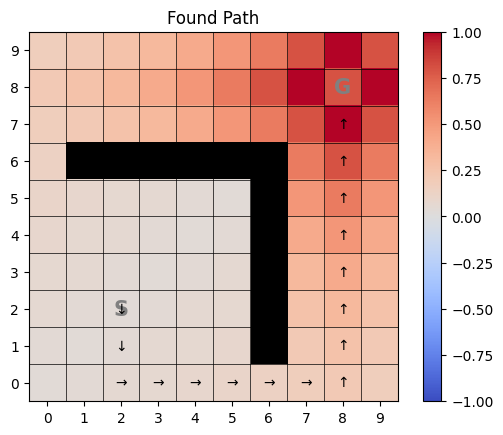

In [8]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_star, max_len=100)
env.image(V_star, policy=pol_star, episode=path, title='Found Path', clim=(-1,1))

In [9]:
Vs = value_iteration(env, discount=.9, precision=0.1, history=True)
Vs

#gridworld_image_list(env, Vs, cmap = "Reds")

Value Iteration: 17it [00:00, 369.84it/s]


[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.]),
 array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 1. , 0.9, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0.9,
        1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.9, 1. , 0.9]),
 array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0. 

In [10]:
gridworld_animate(env, Vs, cmap = "Reds")

**Node:** The state space is swept column-wise from $(0,0)$ to $(9,9)$. 

## Policy Iteration


Policy Iteration: 15it [00:00, 100.80it/s]


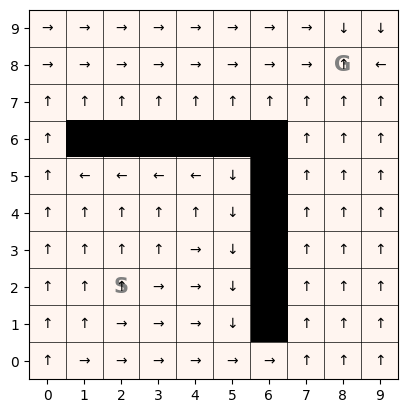

In [11]:
from gym_classics.algorithms.dynamic_programming import policy_iteration

pol_star = policy_iteration(env, discount=.8)

env.image(policy=pol_star)

In [12]:

policy_list, V_list = policy_iteration(env, discount=.8, history=True)

#gridworld_image_list(env, V_list, policies=policy_list, cmap = "Reds")

Policy Iteration: 8it [00:00, 99.59it/s]


In [13]:
gridworld_animate(env, V_list, policies = policy_list, cmap = "Reds")

**Note:** The first value function is shown after the first policy evaluation. This is why actions that lead to the goal state already have a value.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)